# GeBIZ Tender Dataset - Business Intelligence & Visualization

## Purpose
This notebook explores classified government procurement (GeBIZ) tender award data to help you understand:
- **Spending patterns**: Where is the money going?
- **Business categories**: What types of services/products are being procured?
- **Key players**: Which agencies spend the most? Which suppliers win the most contracts?
- **Service types**: Which categories have recurring services? Which are manpower-heavy?
- **Future opportunities**: Where can forecasting and planning focus?

## Data Source
- **Input**: `Dataset/Final/GPGB_enriched_final.csv`
- **Contains**: 12,572 tender records with procurement type, business category, and service flags
- **Important**: Original CSV is read-only. All analysis happens in this notebook.

In [27]:
print("\n" + "="*100)
print("ANALYSIS 5: TIMELINE OF TENDERS (OLDEST TO LATEST)")
print("="*100 + "\n")

# Sort by date and show trend
df_sorted = df.sort_values('award_date')

print(f"Date range: {df_sorted['award_date'].min().date()} to {df_sorted['award_date'].max().date()}\n")

# Group by year to show trend
yearly_summary = df.groupby(df['award_date'].dt.year).agg({
    'tender_no': 'count',
    'awarded_amt': 'sum',
    'supplier_name': 'nunique'
}).round(0)

yearly_summary.columns = ['Tender Count', 'Total Value ($)', 'Unique Companies']

print("TENDERS BY YEAR:\n")
print(f"{'Year':<10} {'Tender Count':<20} {'Total Value ($)':<30} {'Unique Companies':<20}")
print("-" * 100)

for year, row in yearly_summary.iterrows():
    print(f"{int(year):<10} {int(row['Tender Count']):<20} ${row['Total Value ($)']:>28,.0f}  {int(row['Unique Companies']):<20}")

# Create timeline visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Tender count over time
yearly_count = df.groupby(df['award_date'].dt.year).size()
axes[0].plot(yearly_count.index, yearly_count.values, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0].fill_between(yearly_count.index, yearly_count.values, alpha=0.3, color='#3498db')
axes[0].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Tenders', fontsize=11, fontweight='bold')
axes[0].set_title('Timeline: Number of Tenders Issued Per Year', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(yearly_count.index)

# Plot 2: Total value over time
yearly_value = df.groupby(df['award_date'].dt.year)['awarded_amt'].sum()
axes[1].bar(yearly_value.index, yearly_value.values, color='#e74c3c', alpha=0.7, edgecolor='#c0392b')
axes[1].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Total Tender Value ($)', fontsize=11, fontweight='bold')
axes[1].set_title('Timeline: Total Tender Value Per Year', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B' if x >= 1e9 else f'${x/1e6:.0f}M'))
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(yearly_value.index)

plt.tight_layout()
plt.show()

print(f"\n✓ Timeline charts displayed")


ANALYSIS 5: TIMELINE OF TENDERS (OLDEST TO LATEST)



AttributeError: 'str' object has no attribute 'date'

In [28]:
print("\n" + "="*100)
print("ANALYSIS 4: WHICH AGENCY GIVES OUT THE MOST EXPENSIVE TENDERS (BY TOTAL VALUE)")
print("="*100 + "\n")

# Sum awarded amounts by agency
value_by_agency = df.groupby('agency')['awarded_amt'].sum().sort_values(ascending=False)

print(f"{'Rank':<6} {'Agency Name':<50} {'Total Tender Value ($)':<30}")
print("-" * 100)

for idx, (agency, value) in enumerate(value_by_agency.head(20).items(), 1):
    count = len(df[df['agency'] == agency])
    print(f"{idx:<6} {agency:<50} ${value:>28,.2f}  ({count:,} tenders)")

print("\n" + "="*100)
print(f"Top agency by value: {value_by_agency.index[0]} (${value_by_agency.values[0]:,.2f})")
print("="*100)


ANALYSIS 4: WHICH AGENCY GIVES OUT THE MOST EXPENSIVE TENDERS (BY TOTAL VALUE)

Rank   Agency Name                                        Total Tender Value ($)        
----------------------------------------------------------------------------------------------------
1      Housing and Development Board                      $           22,351,550,070.93  (587 tenders)
2      Land Transport Authority                           $            5,098,714,547.53  (410 tenders)
3      Public Utilities Board                             $            3,833,949,030.50  (355 tenders)
4      National Environment Agency                        $            3,568,457,522.79  (318 tenders)
5      Ministry of Home Affairs - Ministry Headquarter 1  $            3,041,441,312.78  (432 tenders)
6      Ministry of Education                              $            2,894,470,631.64  (440 tenders)
7      Ministry of Health-Ministry Headquarter            $            1,929,561,010.11  (338 tenders)
8      J

In [29]:
print("\n" + "="*100)
print("ANALYSIS 3: WHICH AGENCY GIVES OUT THE MOST TENDERS (BY COUNT)")
print("="*100 + "\n")

# Count tenders by agency
tenders_by_agency = df['agency'].value_counts()

print(f"Total agencies issuing tenders: {len(tenders_by_agency):,}\n")
print(f"{'Rank':<6} {'Agency Name':<50} {'Tenders Issued':<20}")
print("-" * 100)

for idx, (agency, count) in enumerate(tenders_by_agency.head(20).items(), 1):
    print(f"{idx:<6} {agency:<50} {count:<20}")

print("\n" + "="*100)
print(f"Top agency by count: {tenders_by_agency.index[0]} ({tenders_by_agency.values[0]:,} tenders)")
print("="*100)


ANALYSIS 3: WHICH AGENCY GIVES OUT THE MOST TENDERS (BY COUNT)

Total agencies issuing tenders: 111

Rank   Agency Name                                        Tenders Issued      
----------------------------------------------------------------------------------------------------
1      People's Association                               717                 
2      Agency for Science, Technology and Research        591                 
3      Housing and Development Board                      587                 
4      Ministry of Finance - Vital                        482                 
5      Ministry of Digital Development and Information    474                 
6      Ministry of Education                              440                 
7      Ministry of Home Affairs - Ministry Headquarter 1  432                 
8      Land Transport Authority                           410                 
9      Ministry of Foreign Affairs                        404                 
10     


ANALYSIS 2: PIE CHART - ALL COMPANIES THAT WON TENDERS

Total unique companies: 4,726



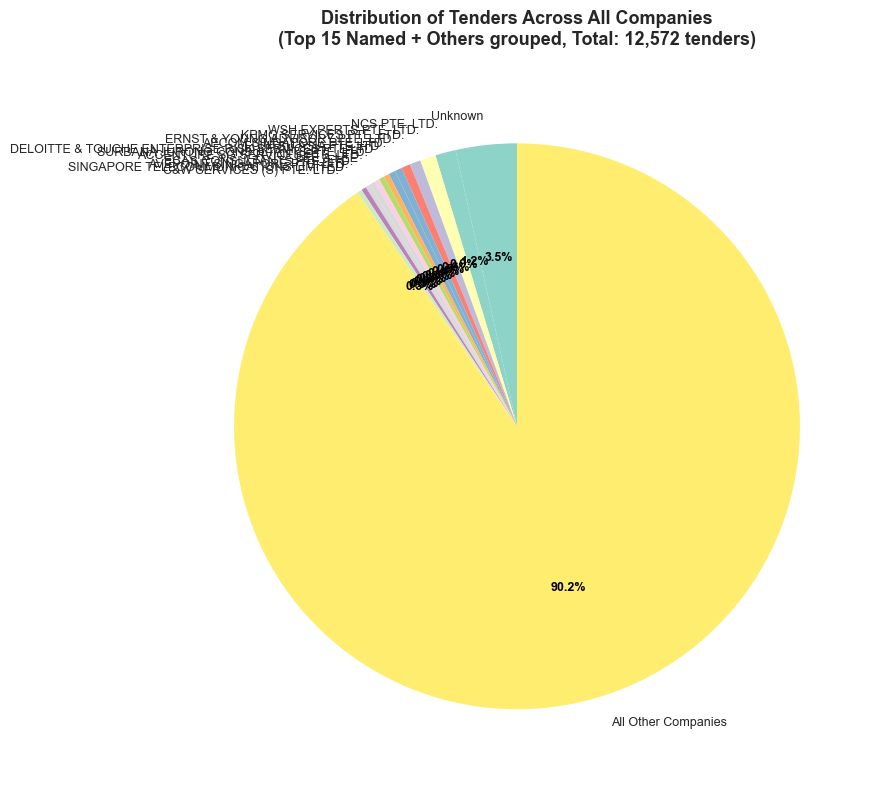

✓ Pie chart displayed


In [30]:
print("\n" + "="*100)
print("ANALYSIS 2: PIE CHART - ALL COMPANIES THAT WON TENDERS")
print("="*100 + "\n")

# Count all companies
all_companies = df['supplier_name'].value_counts()
print(f"Total unique companies: {len(all_companies):,}\n")

# Create pie chart showing top 15 + "Others"
fig, ax = plt.subplots(figsize=(14, 8))

top_n = 15
top_companies = all_companies.head(top_n)
others_count = all_companies.iloc[top_n:].sum()

if others_count > 0:
    pie_data = pd.concat([top_companies, pd.Series({'All Other Companies': others_count})])
else:
    pie_data = top_companies

colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
                                     colors=colors, startangle=90)

ax.set_title(f"Distribution of Tenders Across All Companies\n(Top 15 Named + Others grouped, Total: {all_companies.sum():,} tenders)",
             fontsize=13, fontweight='bold', pad=20)

# Make percentage text readable
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

for text in texts:
    text.set_fontsize(9)

plt.tight_layout()
plt.show()

print(f"✓ Pie chart displayed")

In [31]:
print("\n" + "="*100)
print("ANALYSIS 1: TOP 20 COMPANIES BY TENDER COUNT")
print("="*100 + "\n")

# Get top 20 companies by tender count
top_20_by_count = df['supplier_name'].value_counts().head(20)

print(f"Top 20 companies that won the most tenders:\n")
print(f"{'Rank':<6} {'Company Name':<50} {'Tenders Won':<15} {'Total Value ($)':<20}")
print("-" * 100)

for idx, (company, count) in enumerate(top_20_by_count.items(), 1):
    total_value = df[df['supplier_name'] == company]['awarded_amt'].sum()
    print(f"{idx:<6} {company:<50} {count:<15} ${total_value:>18,.2f}")

# Calculate percentage
total_tenders = len(df)
top_20_total = top_20_by_count.sum()
percentage = (top_20_total / total_tenders) * 100

print("\n" + "="*100)
print(f"Top 20 Companies Account For: {top_20_total:,} tenders out of {total_tenders:,} ({percentage:.1f}%)")
print("="*100)


ANALYSIS 1: TOP 20 COMPANIES BY TENDER COUNT

Top 20 companies that won the most tenders:

Rank   Company Name                                       Tenders Won     Total Value ($)     
----------------------------------------------------------------------------------------------------
1      Unknown                                            438             $              0.00
2      NCS PTE. LTD.                                      147             $    927,658,631.65
3      WSH EXPERTS PTE. LTD.                              114             $    169,743,999.70
4      KPMG SERVICES PTE. LTD.                            78              $     49,445,080.13
5      ERNST & YOUNG ADVISORY PTE. LTD.                   64              $     50,417,455.77
6      AECOM SINGAPORE PTE. LTD.                          51              $    206,256,399.49
7      FUJITSU ASIA PTE LTD                               49              $     76,444,162.10
8      DELOITTE & TOUCHE ENTERPRISE RISK SERVICES PTE 


ANALYSIS 5: TIMELINE OF TENDERS (OLDEST TO LATEST)

Date range: 2020-01-04 00:00:00 to 2025-12-03 00:00:00

TENDERS BY YEAR:

Year       Tender Count         Total Value ($)                Unique Companies    
----------------------------------------------------------------------------------------------------
2020       631                  $               1,263,848,625  514                 
2021       1165                 $               2,771,751,804  947                 
2022       841                  $               2,542,990,742  643                 
2023       954                  $               3,456,677,111  772                 
2024       906                  $               2,957,212,744  696                 
2025       220                  $                 977,450,615  190                 


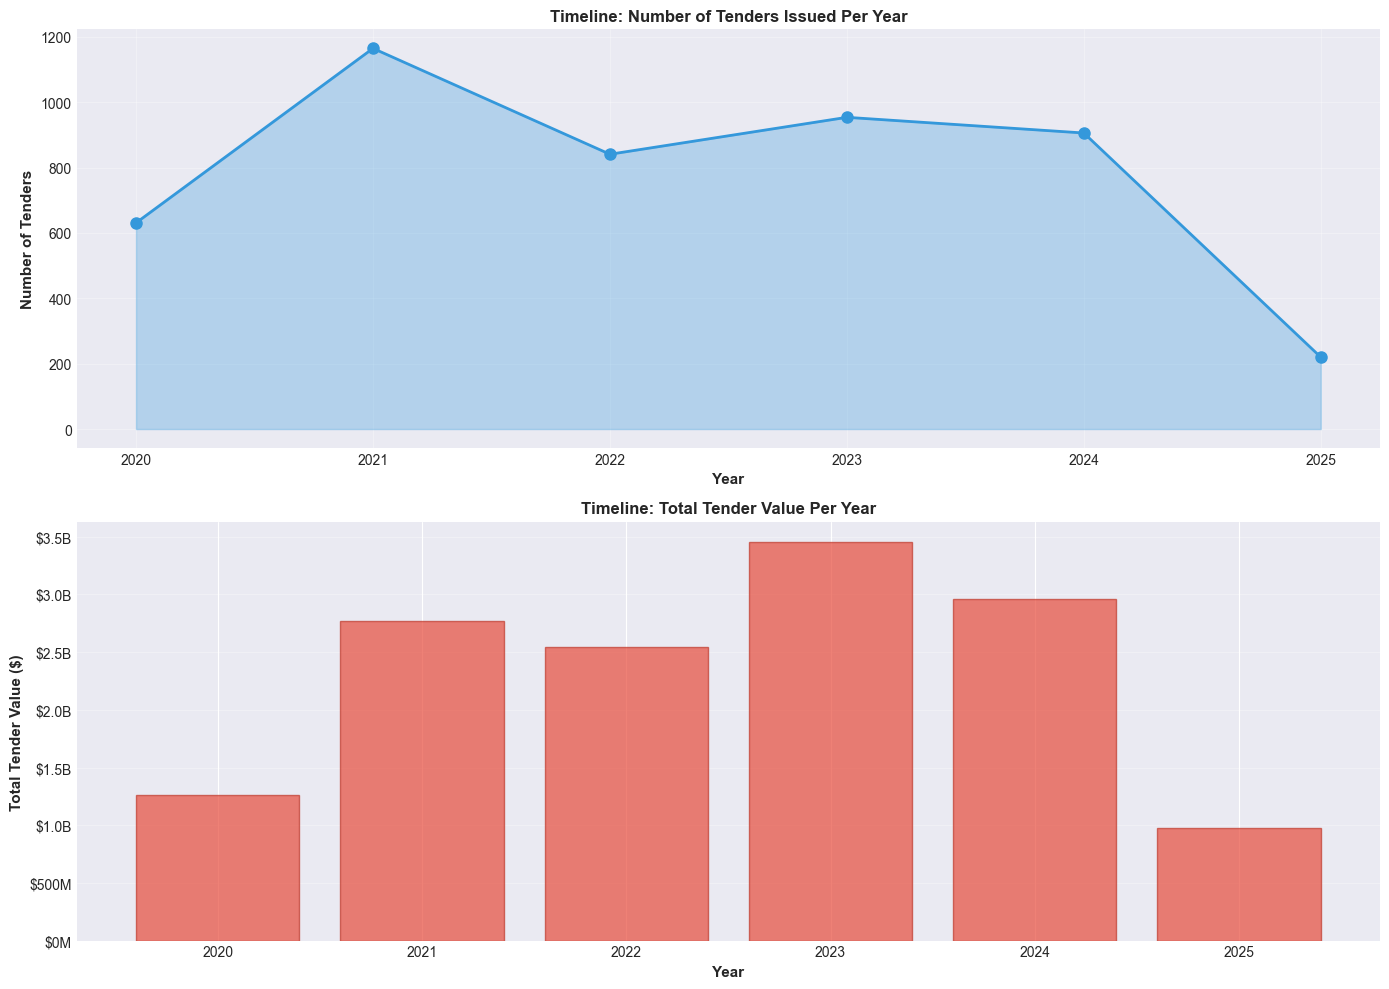


✓ Timeline charts displayed


In [33]:
print("\n" + "="*100)
print("ANALYSIS 5: TIMELINE OF TENDERS (OLDEST TO LATEST)")
print("="*100 + "\n")

# Ensure dates are datetime
df['award_date'] = pd.to_datetime(df['award_date'], errors='coerce')

# Sort by date and show trend
df_sorted = df.sort_values('award_date')

date_min = df_sorted['award_date'].min()
date_max = df_sorted['award_date'].max()

print(f"Date range: {date_min} to {date_max}\n")

# Group by year to show trend
yearly_summary = df.groupby(df['award_date'].dt.year).agg({
    'tender_no': 'count',
    'awarded_amt': 'sum',
    'supplier_name': 'nunique'
}).round(0)

yearly_summary.columns = ['Tender Count', 'Total Value ($)', 'Unique Companies']

print("TENDERS BY YEAR:\n")
print(f"{'Year':<10} {'Tender Count':<20} {'Total Value ($)':<30} {'Unique Companies':<20}")
print("-" * 100)

for year, row in yearly_summary.iterrows():
    print(f"{int(year):<10} {int(row['Tender Count']):<20} ${row['Total Value ($)']:>28,.0f}  {int(row['Unique Companies']):<20}")

# Create timeline visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Tender count over time
yearly_count = df.groupby(df['award_date'].dt.year).size()
axes[0].plot(yearly_count.index, yearly_count.values, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0].fill_between(yearly_count.index, yearly_count.values, alpha=0.3, color='#3498db')
axes[0].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Tenders', fontsize=11, fontweight='bold')
axes[0].set_title('Timeline: Number of Tenders Issued Per Year', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(yearly_count.index)

# Plot 2: Total value over time
yearly_value = df.groupby(df['award_date'].dt.year)['awarded_amt'].sum()
axes[1].bar(yearly_value.index, yearly_value.values, color='#e74c3c', alpha=0.7, edgecolor='#c0392b')
axes[1].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Total Tender Value ($)', fontsize=11, fontweight='bold')
axes[1].set_title('Timeline: Total Tender Value Per Year', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B' if x >= 1e9 else f'${x/1e6:.0f}M'))
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(yearly_value.index)

plt.tight_layout()
plt.show()

print(f"\n✓ Timeline charts displayed")